In [1]:
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import xobjects as xo
import xtrack as xt

import math

import matplotlib.pyplot as plt
import re

import json

import ttline_to_lenustorm as ttline

import scipy
import scipy.constants

from particle import Particle

print(f' Beam parameters : ')
import os

 Beam parameters : 


428.2714285714286


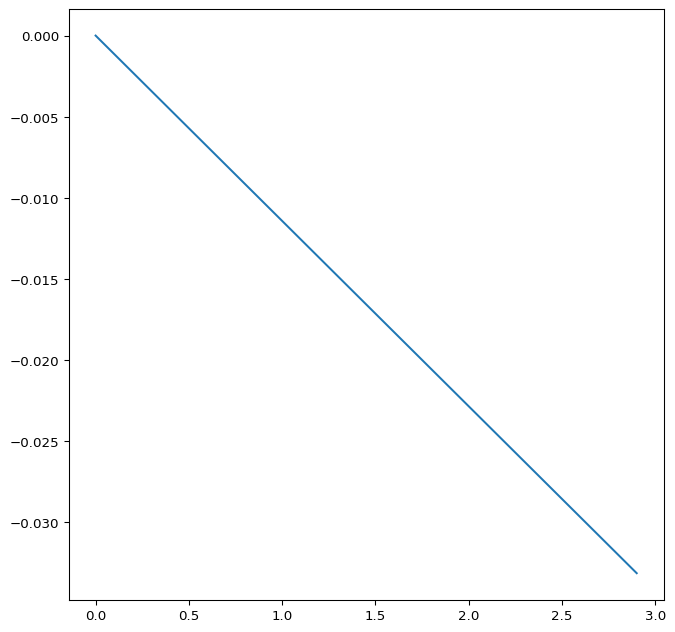

In [2]:

p_injection = 0.700
p_circulating = 0.680

bl = 1.0 # 1 Tm 
theta0 = 299.79*bl/p_injection  # in mrad

print(theta0)


xv = np.arange(0, 3, 0.1)

def pimuseparation(pinj, pcirc, dist, bdl):
    theta_inj = 299.79*bdl/pinj/1000
    theta_circ = 299.79*bdl/pcirc/1000
    return dist*(np.sin(theta_inj)-np.sin(theta_circ))

# plt.plot(xv, xv*theta0*(1-p_circulating/p_injection))
plt.plot(xv, pimuseparation(p_injection, p_circulating, xv, bl))

## 

## LEnuSTORM Fast Simulation


 Paramters LEnuSTORM Fast Simulation (units in GeV)
            injected pion beam:
                pion_energy=0.71378
                pion_ekin=0.57421
                pion_momentum=0.70000
                pion_gamma=5.11411
                pion_decay_length=39.91268 [m]
            stored muon beam:
                muon_momentum=0.4
                muon_beta=0.96684
                muon_lifetime=0.00001
                muon_decay_length=2578.98569
        


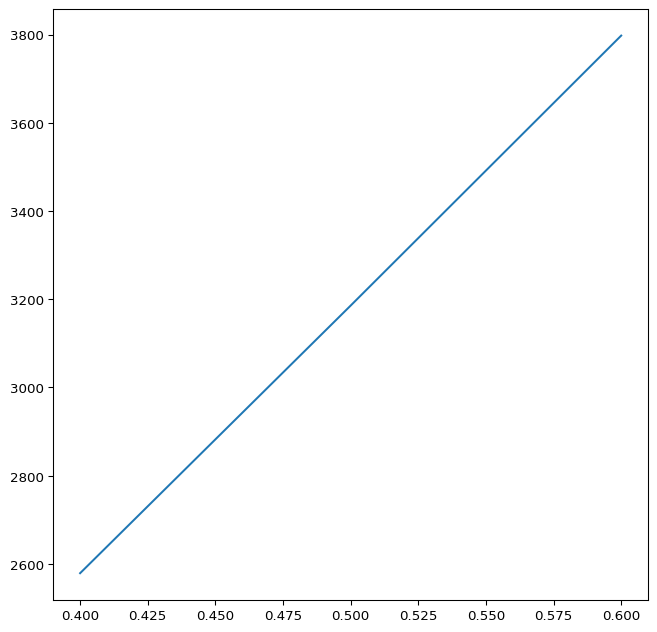

In [18]:
pion = Particle.from_name('pi+')
muon = Particle.from_name('mu+')
proton = Particle.from_name('p')

# particle mass [MeV/c2] --> convert to [GeV/c2]
pmass_gev = proton.mass/1000
pimass_gev = pion.mass/1000
mumass_gev = muon.mass/1000

# print(xx.mass, xx.lifetime*1.0e-9)

# pion beam
pion_momentum = 0.7
pion_bgamma = pion_momentum/pimass_gev
pion_gamma = np.sqrt(pion_bgamma**2+1)
pion_decay_length = pion.lifetime*1.0e-9*scipy.constants.c*pion_gamma
pion_energy = pimass_gev*pion_gamma
pion_ekin = pion_energy - pimass_gev

# muon beam
muon_momentum = 0.4

def muon_beam(p):
    bgamma = p/mumass_gev
    gamma  = np.sqrt(bgamma**2+1)
    beta = bgamma/gamma
    lifetime = muon.lifetime*1.0e-9*gamma
    decay_length = lifetime*scipy.constants.c
    return bgamma, gamma, beta, lifetime, decay_length

muon_bgamma, muon_gamma, muon_beta, muon_lifetime, muon_decay_length = muon_beam(muon_momentum)
print(f''' Paramters LEnuSTORM Fast Simulation (units in GeV)
            injected pion beam:
                {pion_energy=:.5f}
                {pion_ekin=:.5f}
                {pion_momentum=:.5f}
                {pion_gamma=:.5f}
                {pion_decay_length=:.5f} [m]
            stored muon beam:
                {muon_momentum=}
                {muon_beta=:.5f}
                {muon_lifetime=:.5f}
                {muon_decay_length=:.5f}
        ''')

def decay_length(p):
    a, b, c, d, e = muon_beam(p)
    return e

xv = np.arange(0.4, pion_momentum, 0.1)
plt.plot(xv, decay_length(xv))